In [76]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.a import Model_a
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
a = Model_a()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[1.         1.         1.         2.         1.5        2.66666667]]]


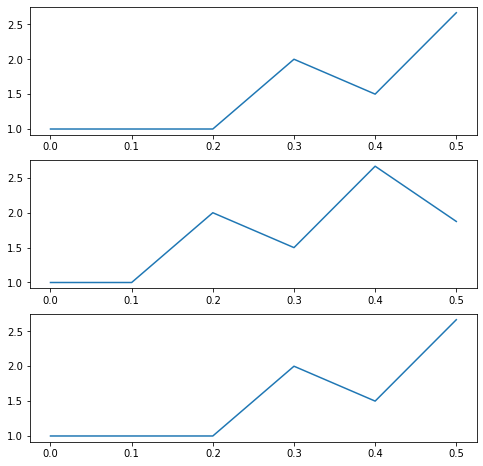

In [187]:
dur = 0.5

a.params.duration = dur
a.params.mufe_init = np.array( [1.] )

target = a.getZeroTarget()
control1 = a.getZeroControl()

#control1[0,0,:] += 3.
control1[0,0,:] += 10.*a.t[:]

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(3, figsize=(8, 8))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
axes[2].plot(a.t, a.state["tau_exc"][0,:])

print(target)

In [179]:
max_cntrl = 100. * 5.
start_step = 11.
cost_params = [1.0, 3.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()

max_it = 5

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  1.5588058590073033
weights =  1.0 3.0
g =  [[[ 0.         -2.56464247 -2.93203909 -2.97384763 -2.67546318
    0.        ]]]
RUN  1 , total integrated cost =  1.169104612671323
weights =  1.0 3.0
g =  [[[ 0.         -0.00192001 -0.00219506 -0.00222636 -0.00200297
    0.        ]]]
RUN  2 , total integrated cost =  1.1691043942554826
weights =  1.0 3.0
g =  [[[0.00000000e+00 2.98602293e-07 3.41378420e-07 3.46246204e-07
   3.11505190e-07 0.00000000e+00]]]
RUN  3 , total integrated cost =  1.1691043942554824
weights =  1.0 3.0
g =  [[[ 0.00000000e+00 -2.94898720e-07 -3.37144292e-07 -3.41951702e-07
   -3.07641581e-07  0.00000000e+00]]]
RUN  4 , total integrated cost =  1.169104394255482
weights =  1.0 3.0
g =  [[[0.00000000e+00 2.82536178e-07 3.23010760e-07 3.27616637e-07
   2.94744842e-07 0.00000000e+00]]]
RUN  5 , total integrated cost =  1.169104394255481
Improved over  5  iterations by  24.999999999999773  percent.


[[[ 0.          0.38954293  0.38954293  0.67076745  0.67076745
   -0.06067324]]]


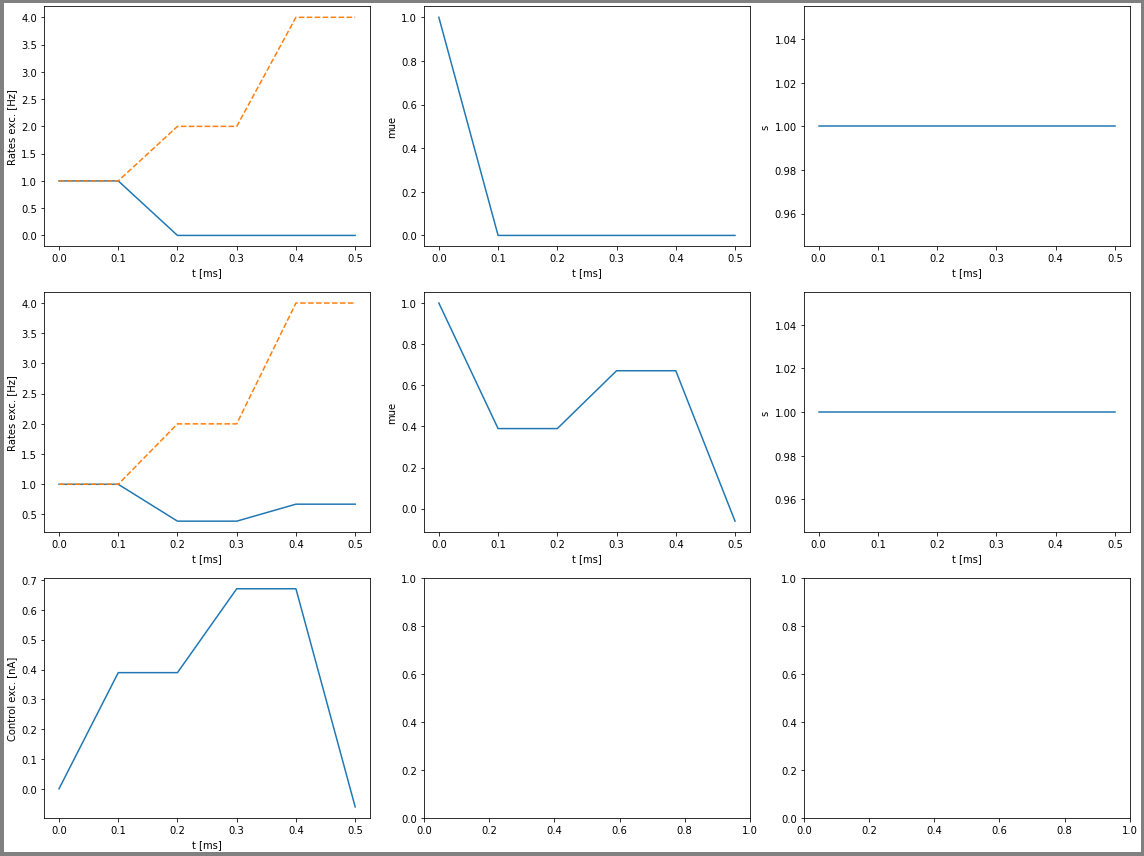

In [167]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [180]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 10

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  1.5588058590073033
RUN  1 , total integrated cost:  1.1691049378345284
RUN  2 , total integrated cost:  1.1691043942561954
change helped, counter =  4
RUN  3 , total integrated cost:  1.1691043942556991
Control only changes marginally.
RUN  4 , total integrated cost:  1.1691043942556991
Improved over  4  iterations by  25  percent.


[[[ 0.          0.50000001  0.5         1.          1.00000002
   -0.06067324]]]


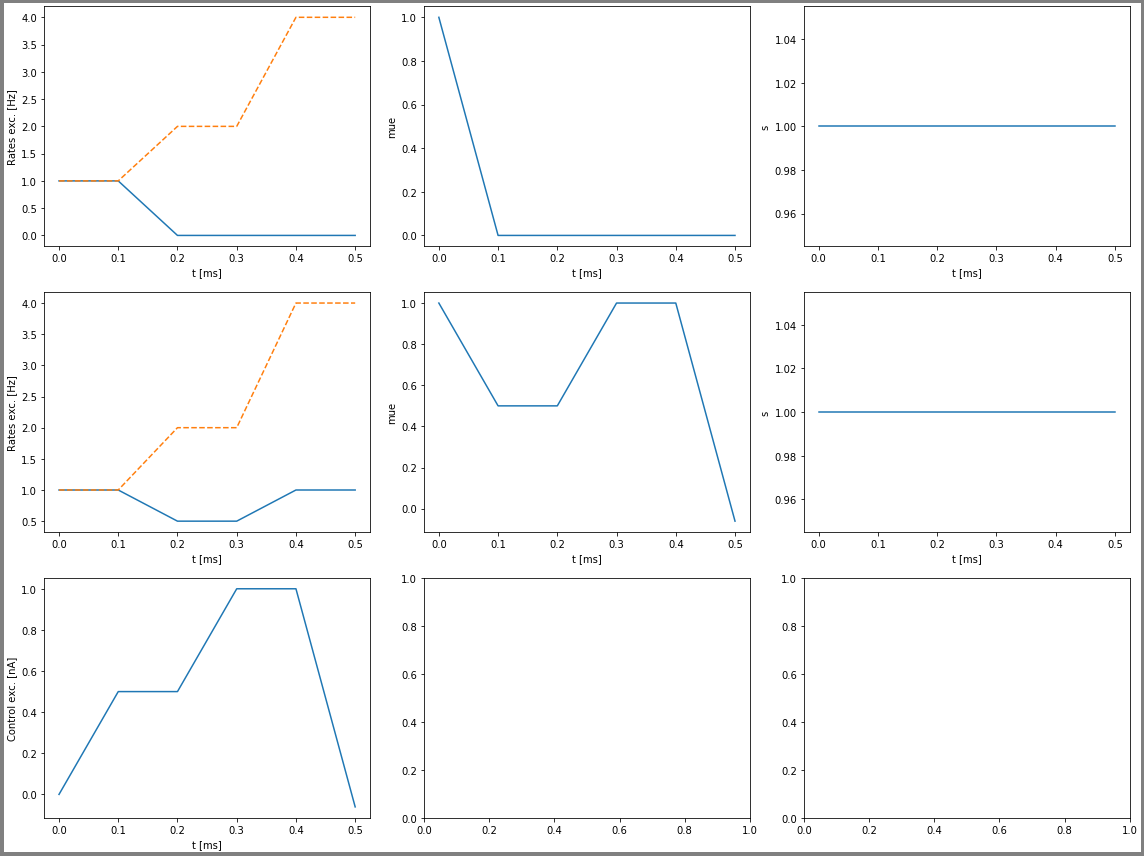

In [169]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

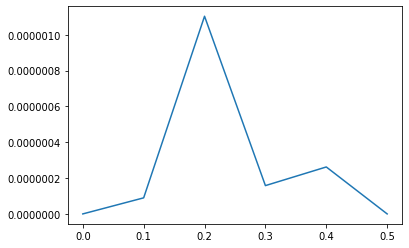

In [181]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


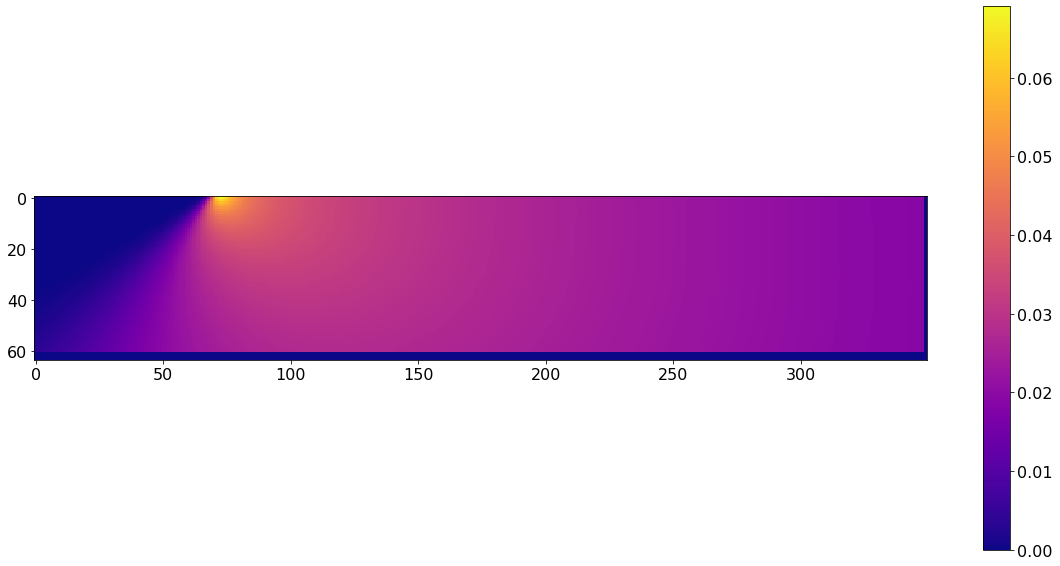

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


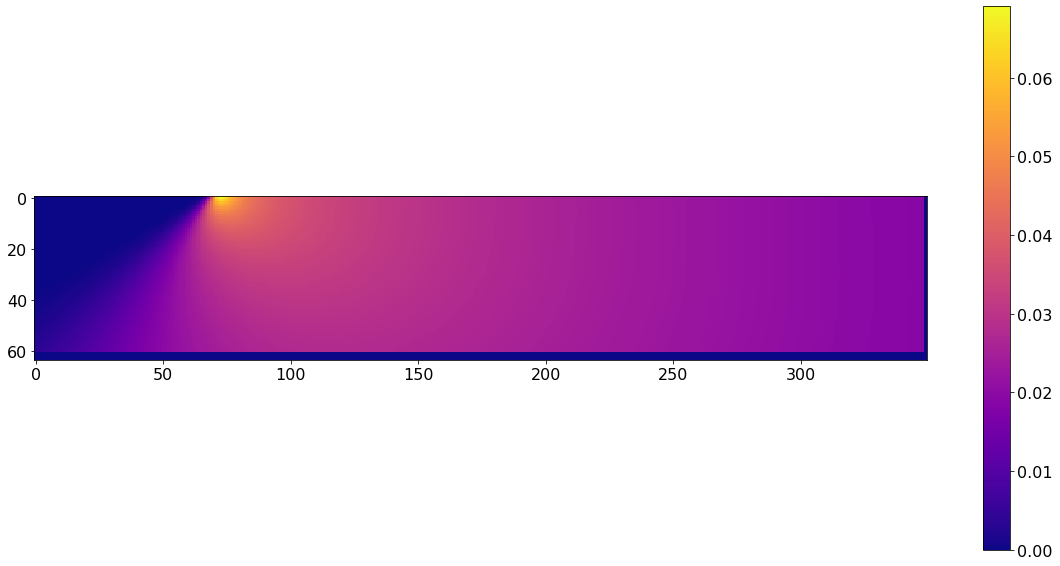

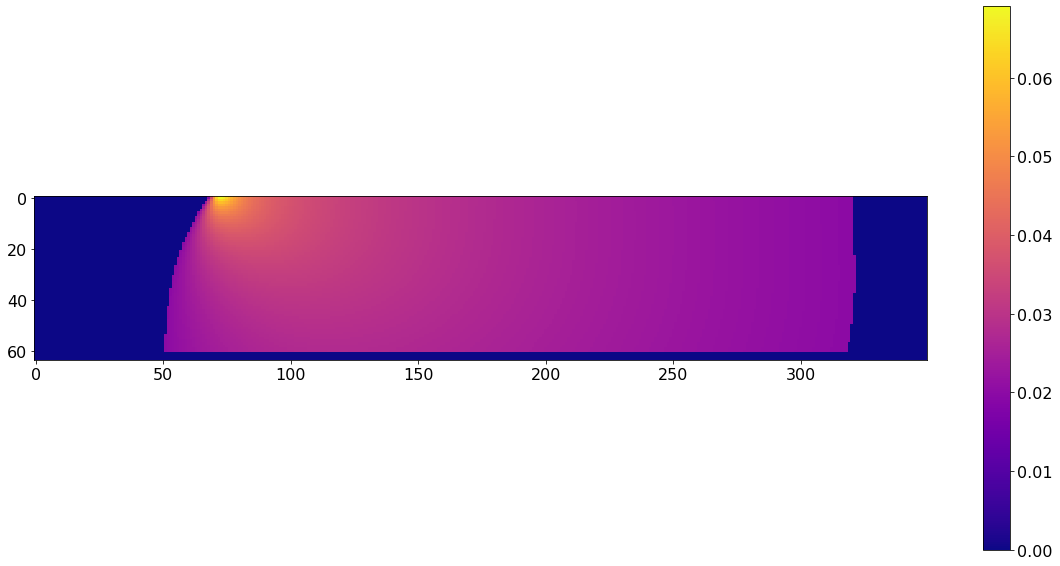

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()